In [1]:
from raprock.neoscan import get_objects

Let's fetch some active object:

In [2]:
objects = get_objects()
print(f"The first ten objects are:\n\n{', '.join(objects[:10])}")

The first ten objects are:

X89330, MOK0002, C45ZWJ1, ST26C13, C1CHM75, C45ZWM1, C1CA1L5, C45ZE41, ZTF10BB, JJDS303


Now query for topocentrical ephemerides at LBT observatory.

In [3]:
from raprock.neoscan import get_ephemeris
from raprock.observatories import LBT

df = get_ephemeris(
    object_name="C1CM1G5",
    observatory=LBT,
    tstart="2026-03-12T18:00",
    tend="2026-03-16T18:00",
    deltat=15, # minutes
)


In [4]:
df

,Mag,Alt,Azi,Airmass,Sun_elev,SolEl,LunEl,LunPh,Phase,Glat,Glon,R,Delta,RA_deg,DEC_deg,MJD,RA_rate_deg,DEC_rate_deg,Vel_deg
0,22.3,-22.0,356.5,inf,48.6,-143.9,131.2,103.9,4.9,56.4,189.2,6.8229,5.9950,154.538138,35.333642,61111.750000,-0.000087,-0.000039,0.000096
1,22.3,-22.1,359.8,inf,50.3,-143.9,131.2,104.0,4.9,56.4,189.2,6.8229,5.9951,154.536533,35.333058,61111.760417,-0.000087,-0.000039,0.000096
2,22.3,-22.0,3.1,inf,51.7,-143.9,131.3,104.1,4.9,56.4,189.2,6.8229,5.9952,154.534925,35.332478,61111.770833,-0.000087,-0.000039,0.000096
3,22.3,-21.8,6.4,inf,52.9,-143.9,131.4,104.2,4.9,56.4,189.2,6.8229,5.9952,154.533317,35.331897,61111.781250,-0.000087,-0.000039,0.000096
4,22.3,-21.4,9.6,inf,53.7,-143.8,131.5,104.3,4.9,56.4,189.2,6.8229,5.9953,154.531713,35.331319,61111.791667,-0.000087,-0.000039,0.000096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,22.4,-20.9,347.3,inf,41.2,-140.7,159.0,150.2,5.3,56.0,189.6,6.8262,6.0268,153.930650,35.101264,61115.708333,-0.000084,-0.000043,0.000094
381,22.4,-21.5,350.6,inf,43.6,-140.7,158.9,150.3,5.3,56.0,189.6,6.8262,6.0269,153.929117,35.100619,61115.718750,-0.000084,-0.000043,0.000094
382,22.4,-22.0,353.8,inf,46.0,-140.7,158.9,150.4,5.3,56.0,189.6,6.8262,6.0270,153.927583,35.099975,61115.729167,-0.000084,-0.000043,0.000094
383,22.4,-22.2,357.1,inf,48.1,-140.7,158.8,150.4,5.3,56.0,189.6,6.8263,6.0271,153.926050,35.099331,61115.739583,-0.000084,-0.000043,0.000094


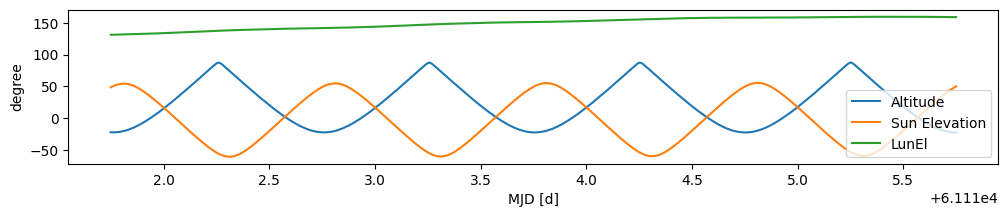

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))
plt.plot(df["MJD"], df["Alt"], label="Altitude")
plt.plot(df["MJD"], df["Sun_elev"], label="Sun Elevation")
plt.plot(df["MJD"], df["LunEl"], label="LunEl")
plt.xlabel("MJD [d]"); plt.ylabel("degree"); plt.legend(loc=4)
plt.show()


# Finding opportunity windows for observations

We will require:
1. the sun to have set (according to the astronomical definition of twilight).
2. the object to be higher than a threshold altitude at observatory.
3. enough time for exposure.

Given these, we find the opportunity windows for starting an object observation.

In [13]:
from raprock.pipes import after_twilight, not_moon_occulted, higher_than, longer_than, start_observation_between
from raprock.utils import TWILIGHTS

PHASE = "nautical"
MINH = 25 # degrees
EXPOSURE_LEN = 120 # minutes
_df = (df
    .pipe(after_twilight, phase=PHASE)
    .pipe(not_moon_occulted)
    .pipe(higher_than, deg=MINH)
    .pipe(longer_than, duration_min=EXPOSURE_LEN)
)
windows = start_observation_between(_df, EXPOSURE_LEN)


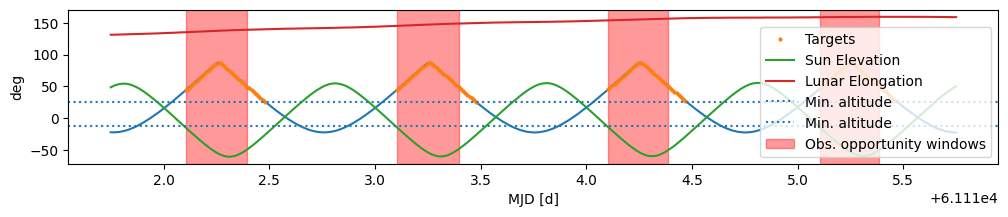

In [12]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 2))
plt.plot(df["MJD"], df["Alt"],)
plt.plot(_df["MJD"], _df["Alt"], "o", ms=2, label="Targets")
plt.plot(df["MJD"], df["Sun_elev"], label="Sun Elevation")
plt.plot(df["MJD"], df["LunEl"], label="Lunar Elongation")
plt.axhline(MINH, linestyle="dotted", label="Min. altitude")
plt.axhline(TWILIGHTS[PHASE], linestyle="dotted", label="Min. altitude")
label_set = False
for s, e in windows:
    plt.axvspan(s, e, label="Obs. opportunity windows" if not label_set else "", color="red", alpha=0.4)
    label_set = True
plt.xlabel("MJD [d]"); plt.ylabel("deg"); plt.legend(loc=4)
plt.show()